In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, f1_score, 
                             roc_auc_score, confusion_matrix,
                             classification_report)

print('Libraries imported!')

Libraries imported!


In [2]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_train = pd.read_csv(f'{path}\\X_train_tabular.csv')
X_test  = pd.read_csv(f'{path}\\X_test_tabular.csv')
y_train = pd.read_csv(f'{path}\\y_train_tabular.csv').squeeze()
y_test  = pd.read_csv(f'{path}\\y_test_tabular.csv').squeeze()

print('Data loaded!')
print(f'Training shape : {X_train.shape}')
print(f'Testing shape  : {X_test.shape}')

Data loaded!
Training shape : (1719, 32)
Testing shape  : (430, 32)


In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=2,
        random_state=42,
        eval_metric='logloss'
    ),
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
}

print('Models defined!')
for name in models:
    print(f'  → {name}')

Models defined!
  → Logistic Regression
  → Random Forest
  → XGBoost
  → SVM


In [4]:
results = {}

for name, model in models.items():
    print(f'\nTraining: {name}...')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy' : round(acc * 100, 2),
        'F1-Score' : round(f1  * 100, 2),
        'ROC-AUC'  : round(auc * 100, 2)
    }
    
    print(f'  ✅ Accuracy : {acc*100:.2f}%')
    print(f'  ✅ F1-Score : {f1*100:.2f}%')
    print(f'  ✅ ROC-AUC  : {auc*100:.2f}%')

print('\nAll models trained!')


Training: Logistic Regression...
  ✅ Accuracy : 81.63%
  ✅ F1-Score : 81.96%
  ✅ ROC-AUC  : 88.31%

Training: Random Forest...
  ✅ Accuracy : 92.79%
  ✅ F1-Score : 92.70%
  ✅ ROC-AUC  : 94.46%

Training: XGBoost...
  ✅ Accuracy : 94.88%
  ✅ F1-Score : 94.87%
  ✅ ROC-AUC  : 94.39%

Training: SVM...
  ✅ Accuracy : 84.19%
  ✅ F1-Score : 84.38%
  ✅ ROC-AUC  : 89.74%

All models trained!


In [5]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)

print('=' * 55)
print('         TABULAR ML MODELS — RESULTS')
print('=' * 55)
print(results_df.to_string())
print('=' * 55)
print(f'\nBest Model: {results_df["F1-Score"].idxmax()}')
print(f'   F1-Score : {results_df["F1-Score"].max()}%')

         TABULAR ML MODELS — RESULTS
                     Accuracy  F1-Score  ROC-AUC
XGBoost                 94.88     94.87    94.39
Random Forest           92.79     92.70    94.46
SVM                     84.19     84.38    89.74
Logistic Regression     81.63     81.96    88.31

Best Model: XGBoost
   F1-Score : 94.87%


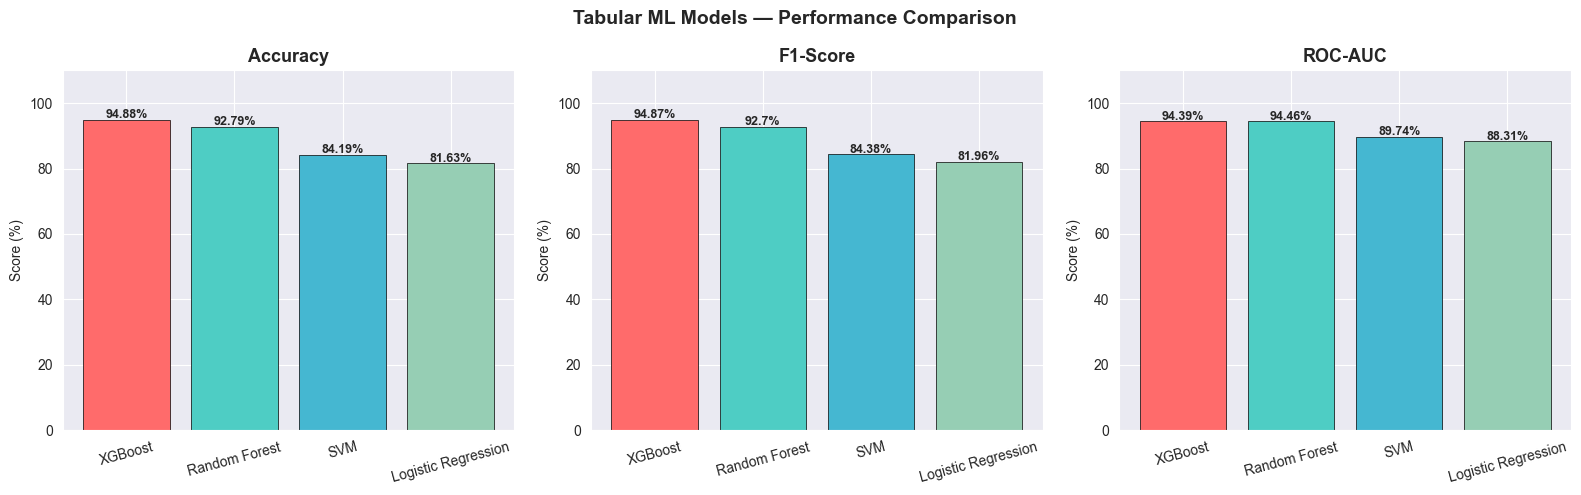

Chart saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors    = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, metric in enumerate(metrics):
    values = results_df[metric]
    bars   = axes[idx].bar(results_df.index, values,
                           color=colors, edgecolor='black',
                           linewidth=0.5)
    
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Score (%)')
    axes[idx].set_ylim(0, 110)
    axes[idx].tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2.,
                       bar.get_height() + 0.5,
                       f'{val}%', ha='center',
                       fontsize=9, fontweight='bold')

plt.suptitle('Tabular ML Models — Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

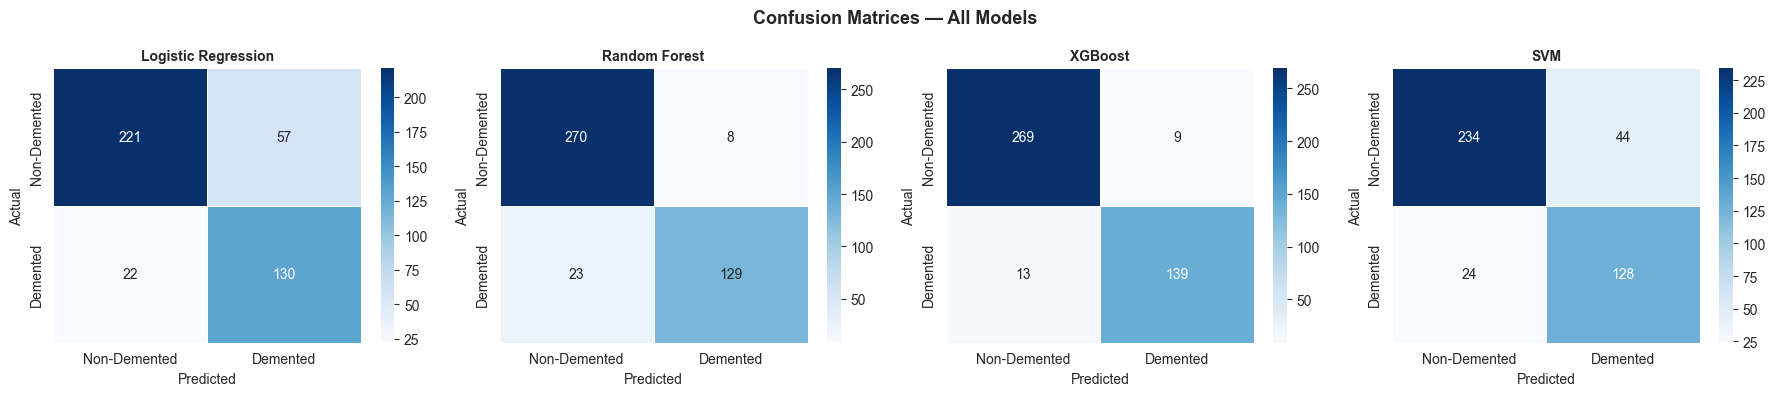

Confusion matrices saved!


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
labels    = ['Non-Demented', 'Demented']

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[idx], linewidths=0.5)
    
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_tabular.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved!')

In [8]:
best_model_name = results_df['F1-Score'].idxmax()
best_model      = models[best_model_name]

y_pred = best_model.predict(X_test)

print(f'Classification Report — {best_model_name}')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=['Non-Demented', 'Demented']))

Classification Report — XGBoost
              precision    recall  f1-score   support

Non-Demented       0.95      0.97      0.96       278
    Demented       0.94      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430


In [9]:
import os

save_path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

results_df.to_csv(f'{save_path}\\tabular_ml_results.csv')

print('Results saved!')
print('\n' + '=' * 50)
print('    TABULAR ML MODELS — COMPLETE!')
print('=' * 50)
print(results_df.to_string())
print('=' * 50)

Results saved!

    TABULAR ML MODELS — COMPLETE!
                     Accuracy  F1-Score  ROC-AUC
XGBoost                 94.88     94.87    94.39
Random Forest           92.79     92.70    94.46
SVM                     84.19     84.38    89.74
Logistic Regression     81.63     81.96    88.31


In [10]:
# Check karo actual data mein
# Demented patients ki values kya hain

import pandas as pd
import numpy as np

path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_test = pd.read_csv(f'{path}\\X_test_tabular.csv')
y_test = pd.read_csv(f'{path}\\y_test_tabular.csv').squeeze()

# Sirf Demented patients
demented = X_test[y_test == 1]
normal   = X_test[y_test == 0]

print('DEMENTED patients average values:')
print(demented.mean()[['MMSE', 
                        'FunctionalAssessment',
                        'ADL',
                        'MemoryComplaints',
                        'BehavioralProblems']].round(2))

print('\nNORMAL patients average values:')
print(normal.mean()[['MMSE',
                     'FunctionalAssessment', 
                     'ADL',
                     'MemoryComplaints',
                     'BehavioralProblems']].round(2))

DEMENTED patients average values:
MMSE                   -0.30
FunctionalAssessment   -0.55
ADL                    -0.41
MemoryComplaints        0.37
BehavioralProblems      0.57
dtype: float64

NORMAL patients average values:
MMSE                    0.21
FunctionalAssessment    0.20
ADL                     0.24
MemoryComplaints       -0.15
BehavioralProblems     -0.08
dtype: float64
